# HH Alignment Exploratory Analysis

Lightweight notebook for inspecting HH alignment CSV outputs. This notebook does not run model inference and does not modify experiment code. Treat plots here as draft diagnostics, not final paper figures.

## 1. Imports and Config

Set `RESULTS_DIR` to a directory containing one or more `pair_metrics.csv` files. The loader searches recursively.

In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 80)

# Configure this path before running the notebook.
RESULTS_DIR = Path("./results")
CSV_GLOB = "**/pair_metrics.csv"

REQUIRED_COLUMNS = {
    "layer",
    "pair_index",
    "left_index",
    "right_index",
    "dot",
    "cosine",
    "metric_variant",
}

NUMERIC_COLUMNS = ["layer", "pair_index", "left_index", "right_index", "dot", "cosine"]

## 2. Load CSVs

Load all matching CSV files and attach lightweight provenance columns inferred from file paths. Adjust `infer_metadata_from_path` if your result layout changes.

In [167]:
def find_metric_csvs(results_dir=RESULTS_DIR, pattern=CSV_GLOB):
    results_dir = Path(results_dir)
    return sorted(results_dir.glob(pattern))


def infer_metadata_from_path(path, results_dir=RESULTS_DIR):
    """Infer experiment/model labels from the path without assuming a fixed layout."""
    path = Path(path)
    try:
        parts = path.relative_to(results_dir).parts
    except ValueError:
        parts = path.parts

    return {
        "source_csv": str(path),
        "experiment": parts[0] if len(parts) > 2 else None,
        "model": parts[1] if len(parts) > 3 else None,
    }


def load_metric_csv(path, results_dir=RESULTS_DIR):
    df = pd.read_csv(path)
    meta = infer_metadata_from_path(path, results_dir=results_dir)
    for key, value in meta.items():
        df[key] = value
    return df


def load_all_metrics(results_dir=RESULTS_DIR, pattern=CSV_GLOB):
    paths = find_metric_csvs(results_dir, pattern)
    if not paths:
        raise FileNotFoundError(f"No CSV files matched {pattern!r} under {results_dir}")
    return pd.concat([load_metric_csv(path, results_dir) for path in paths], ignore_index=True), paths


def load_one_experiment(experiment=None, model=None, results_dir=RESULTS_DIR, csv_path=None):
    """Load one experiment/model CSV without scanning every result into memory."""
    results_dir = Path(results_dir)
    if csv_path is None:
        if experiment is None:
            raise ValueError("Pass experiment=... or csv_path=...")
        search_root = results_dir / experiment
        if model is not None:
            search_root = search_root / model
        paths = sorted(search_root.glob(CSV_GLOB))
    else:
        csv_path = Path(csv_path)
        paths = [csv_path] if csv_path.is_file() else sorted(csv_path.glob(CSV_GLOB))

    if not paths:
        target = csv_path if csv_path is not None else search_root
        raise FileNotFoundError(f"No CSV files found under {target}")
    if len(paths) > 1:
        raise ValueError(f"Expected one CSV, found {len(paths)}. Pass model=... or csv_path=... to disambiguate.")

    return load_metric_csv(paths[0], results_dir=results_dir), paths[0]

metrics_df, csv_path = load_one_experiment(csv_path="results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3.5-0.8B/hh_alignment/pair_metrics.csv")


#_, csv_paths = load_all_metrics()
print(f"Loaded {len(csv_paths)} CSV file(s), {len(metrics_df):,} rows")
csv_paths[:30]

Loaded 12 CSV file(s), 1,296 rows


[PosixPath('results/GSM8K_try/Llama-3.2-3B/hh_alignment/pair_metrics.csv'),
 PosixPath('results/GSM8K_try/Llama-3.2-3B-Instruct/hh_alignment/pair_metrics.csv'),
 PosixPath('results/GSM8K_try/Mistral-7B-v0.1/hh_alignment/pair_metrics.csv'),
 PosixPath('results/GSM8K_try/Qwen2.5-7B-Instruct/hh_alignment/pair_metrics.csv'),
 PosixPath('results/GSM8K_try/Qwen2.5-Math-7B-Instruct/hh_alignment/pair_metrics.csv'),
 PosixPath('results/GSM8K_try/Qwen3.5-0.8B/hh_alignment/pair_metrics.csv'),
 PosixPath('results/GSM8K_try/deepseek-llm-7b-chat/hh_alignment/pair_metrics.csv'),
 PosixPath('results/hh_dataset_combos/gsm8k_to_mmlu/Llama-3.2-3B/hh_alignment/pair_metrics.csv'),
 PosixPath('results/hh_dataset_combos/gsm8k_to_mmlu/Llama-3.2-3B-Instruct/hh_alignment/pair_metrics.csv'),
 PosixPath('results/hh_dataset_combos/gsm8k_to_mmlu/Mistral-7B-v0.1/hh_alignment/pair_metrics.csv'),
 PosixPath('results/hh_dataset_combos/gsm8k_to_mmlu/Qwen2.5-7B-Instruct/hh_alignment/pair_metrics.csv'),
 PosixPath('result

## 3. Schema Validation

Check that required columns exist and coerce key numeric columns. This catches stale CSVs or partial outputs before plotting.

In [168]:
def validate_schema(df, required_columns=REQUIRED_COLUMNS):
    missing = sorted(required_columns - set(df.columns))
    if missing:
        raise ValueError(f"Missing required columns: {missing}")
    return True


def coerce_numeric_columns(df, columns=NUMERIC_COLUMNS):
    out = df.copy()
    for col in columns:
        if col in out.columns:
            out[col] = pd.to_numeric(out[col], errors="coerce")
    return out


validate_schema(metrics_df)
metrics_df = coerce_numeric_columns(metrics_df)
metrics_df.dtypes.sort_index()

cosine                         float64
dot                            float64
experiment                      object
layer                            int64
left_dataset                    object
left_domain                     object
left_example_id                 object
left_hidden_attention_mask       int64
left_hidden_pos                  int64
left_index                       int64
left_input_token_id              int64
left_input_token_str            object
left_label_attention_mask        int64
left_label_pos                   int64
left_label_token_id              int64
left_label_token_str            object
left_norm                      float64
left_raw_index                   int64
left_sample_index                int64
left_sequence_index              int64
metric_variant                  object
model                           object
pair_index                       int64
right_dataset                   object
right_domain                    object
right_example_id         

## 4. Basic Sanity Checks

Check row counts, finite values, cosine range, and available categories. Tiny cosine overshoots can happen numerically; inspect rather than overinterpret.

In [169]:
def sanity_report(df):
    report = {
        "rows": len(df),
        "files": df["source_csv"].nunique() if "source_csv" in df else None,
        "layers": sorted(df["layer"].dropna().unique().tolist()),
        "metric_variants": sorted(df["metric_variant"].dropna().unique().tolist()),
        "cosine_min": df["cosine"].min(),
        "cosine_max": df["cosine"].max(),
        "cosine_nonfinite": int((~np.isfinite(df["cosine"])).sum()),
        "dot_nonfinite": int((~np.isfinite(df["dot"])).sum()),
        "cosine_outside_unit": int(((df["cosine"] < -1.000001) | (df["cosine"] > 1.000001)).sum()),
    }
    return pd.Series(report)


sanity_report(metrics_df)

rows                                    1296
files                                      1
layers                 [0, 4, 8, 12, 20, 24]
metric_variants              [centered, raw]
cosine_min                         -0.311107
cosine_max                          0.684932
cosine_nonfinite                           0
dot_nonfinite                              0
cosine_outside_unit                        0
dtype: object

Reusable filters. These keep downstream cells short and make comparisons explicit.

In [170]:
def filter_metrics(
    df,
    dataset=None,
    model=None,
    layer=None,
    pair_type=None,
    metric_variant=None,
    centered=None,
):
    out = df
    if dataset is not None and "dataset" in out.columns:
        out = out[out["dataset"].isin(np.atleast_1d(dataset))]
    if model is not None and "model" in out.columns:
        out = out[out["model"].isin(np.atleast_1d(model))]
    if layer is not None:
        out = out[out["layer"].isin(np.atleast_1d(layer))]
    if pair_type is not None and "pair_type" in out.columns:
        out = out[out["pair_type"].isin(np.atleast_1d(pair_type))]
    if metric_variant is not None:
        out = out[out["metric_variant"].isin(np.atleast_1d(metric_variant))]
    if centered is not None:
        wanted = "centered" if centered else "raw"
        out = out[out["metric_variant"] == wanted]
    return out.copy()


def numeric_summary(df, group_cols):
    return (
        df.groupby(group_cols, dropna=False)
        .agg(
            n=("cosine", "size"),
            dot_mean=("dot", "mean"),
            dot_min=("dot", "min"),
            dot_max=("dot", "max"),
            cosine_mean=("cosine", "mean"),
            cosine_min=("cosine", "min"),
            cosine_max=("cosine", "max"),
            cosine_neg_frac=("cosine", lambda x: float((x < 0).mean())),
            dot_neg_frac=("dot", lambda x: float((x < 0).mean())),
        )
        .reset_index()
        .sort_values(group_cols)
    )


numeric_summary(metrics_df, ["metric_variant"]).head()

,metric_variant,n,dot_mean,dot_min,dot_max,cosine_mean,cosine_min,cosine_max,cosine_neg_frac,dot_neg_frac
0,centered,648,-19.092820,-1877.673096,4607.591309,-0.018930,-0.311107,0.536817,0.591049,0.591049
1,raw,648,802.801035,-0.128556,9122.124023,0.301518,-0.238665,0.684932,0.023148,0.023148


## 5. Raw vs Centered Comparison

Compare raw and centered metrics at the same grouping level. This is a diagnostic table only.

In [171]:
raw_centered_summary = numeric_summary(metrics_df, ["source_csv", "layer", "metric_variant"])
raw_centered_summary.head(20)

,source_csv,layer,metric_variant,n,dot_mean,dot_min,dot_max,cosine_mean,cosine_min,cosine_max,cosine_neg_frac,dot_neg_frac
0,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,0,centered,108,-0.003486,-0.098722,0.127673,-0.020568,-0.198686,0.357935,0.583333,0.583333
1,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,0,raw,108,0.181366,-0.128556,0.452296,0.311497,-0.238665,0.627696,0.138889,0.138889
2,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,4,centered,108,-0.018897,-0.405355,0.786225,-0.020818,-0.237181,0.430287,0.574074,0.574074
3,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,4,raw,108,0.555467,0.276159,0.879397,0.237824,0.117484,0.458055,0.000000,0.000000
4,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,8,centered,108,-0.021073,-0.578289,1.183421,-0.017502,-0.311107,0.536817,0.564815,0.564815
5,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,8,raw,108,0.766369,0.389106,1.464290,0.265581,0.129781,0.588897,0.000000,0.000000
6,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,12,centered,108,-0.027424,-0.653613,1.221183,-0.016214,-0.267780,0.447764,0.546296,0.546296
7,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,12,raw,108,0.944283,0.527717,1.626283,0.257995,0.134287,0.519261,0.000000,0.000000
8,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,20,centered,108,-0.251579,-5.143476,12.468875,-0.019459,-0.228526,0.436057,0.648148,0.648148
9,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,20,raw,108,18.121956,8.230251,32.403919,0.417918,0.253117,0.684932,0.000000,0.000000


In [172]:
def pivot_raw_centered(summary_df, value="cosine_mean"):
    idx_cols = [c for c in ["source_csv", "model", "layer"] if c in summary_df.columns]
    return summary_df.pivot_table(index=idx_cols, columns="metric_variant", values=value).reset_index()
pivot_raw_centered(raw_centered_summary, value="cosine_mean").head(20)

metric_variant,source_csv,layer,centered,raw
0,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,0,-0.020568,0.311497
1,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,4,-0.020818,0.237824
2,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,8,-0.017502,0.265581
3,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,12,-0.016214,0.257995
4,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,20,-0.019459,0.417918
5,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,24,-0.019020,0.318295


## 6. Layer-wise Summaries

Inspect how dot/cosine summaries vary across layers. Keep an eye on counts when comparing across files.

In [173]:
layer_summary = numeric_summary(metrics_df, ["source_csv", "layer", "metric_variant"])
layer_summary.head(30)

,source_csv,layer,metric_variant,n,dot_mean,dot_min,dot_max,cosine_mean,cosine_min,cosine_max,cosine_neg_frac,dot_neg_frac
0,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,0,centered,108,-0.003486,-0.098722,0.127673,-0.020568,-0.198686,0.357935,0.583333,0.583333
1,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,0,raw,108,0.181366,-0.128556,0.452296,0.311497,-0.238665,0.627696,0.138889,0.138889
2,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,4,centered,108,-0.018897,-0.405355,0.786225,-0.020818,-0.237181,0.430287,0.574074,0.574074
3,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,4,raw,108,0.555467,0.276159,0.879397,0.237824,0.117484,0.458055,0.000000,0.000000
4,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,8,centered,108,-0.021073,-0.578289,1.183421,-0.017502,-0.311107,0.536817,0.564815,0.564815
5,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,8,raw,108,0.766369,0.389106,1.464290,0.265581,0.129781,0.588897,0.000000,0.000000
6,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,12,centered,108,-0.027424,-0.653613,1.221183,-0.016214,-0.267780,0.447764,0.546296,0.546296
7,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,12,raw,108,0.944283,0.527717,1.626283,0.257995,0.134287,0.519261,0.000000,0.000000
8,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,20,centered,108,-0.251579,-5.143476,12.468875,-0.019459,-0.228526,0.436057,0.648148,0.648148
9,results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3....,20,raw,108,18.121956,8.230251,32.403919,0.417918,0.253117,0.684932,0.000000,0.000000


## 7. Pair-type Comparison

If pair type is present, compare same-sample/cross-sample/all pair outputs. Older CSVs may not include this column.

In [174]:
if "pair_type" in metrics_df.columns:
    pair_type_summary = numeric_summary(metrics_df, ["pair_type", "layer", "metric_variant"])
    display(pair_type_summary.head(30))
else:
    print("No pair_type column found in these CSV files.")

No pair_type column found in these CSV files.


## 8. Dataset/model Comparison

Compare files/models only when metadata is available or inferable from paths. This avoids assuming one fixed experiment layout.

In [175]:
comparison_cols = [c for c in ["experiment", "model", "layer", "metric_variant"] if c in metrics_df.columns]
dataset_model_summary = numeric_summary(metrics_df, comparison_cols)
dataset_model_summary.head(40)

,experiment,model,layer,metric_variant,n,dot_mean,dot_min,dot_max,cosine_mean,cosine_min,cosine_max,cosine_neg_frac,dot_neg_frac
0,hh_dataset_combos,gsm8k_to_mmlu,0,centered,108,-0.003486,-0.098722,0.127673,-0.020568,-0.198686,0.357935,0.583333,0.583333
1,hh_dataset_combos,gsm8k_to_mmlu,0,raw,108,0.181366,-0.128556,0.452296,0.311497,-0.238665,0.627696,0.138889,0.138889
2,hh_dataset_combos,gsm8k_to_mmlu,4,centered,108,-0.018897,-0.405355,0.786225,-0.020818,-0.237181,0.430287,0.574074,0.574074
3,hh_dataset_combos,gsm8k_to_mmlu,4,raw,108,0.555467,0.276159,0.879397,0.237824,0.117484,0.458055,0.000000,0.000000
4,hh_dataset_combos,gsm8k_to_mmlu,8,centered,108,-0.021073,-0.578289,1.183421,-0.017502,-0.311107,0.536817,0.564815,0.564815
5,hh_dataset_combos,gsm8k_to_mmlu,8,raw,108,0.766369,0.389106,1.464290,0.265581,0.129781,0.588897,0.000000,0.000000
6,hh_dataset_combos,gsm8k_to_mmlu,12,centered,108,-0.027424,-0.653613,1.221183,-0.016214,-0.267780,0.447764,0.546296,0.546296
7,hh_dataset_combos,gsm8k_to_mmlu,12,raw,108,0.944283,0.527717,1.626283,0.257995,0.134287,0.519261,0.000000,0.000000
8,hh_dataset_combos,gsm8k_to_mmlu,20,centered,108,-0.251579,-5.143476,12.468875,-0.019459,-0.228526,0.436057,0.648148,0.648148
9,hh_dataset_combos,gsm8k_to_mmlu,20,raw,108,18.121956,8.230251,32.403919,0.417918,0.253117,0.684932,0.000000,0.000000


## 9. Scratch Plotting Area

Simple placeholder plots for quick inspection. Replace or refine later for paper-quality figures.

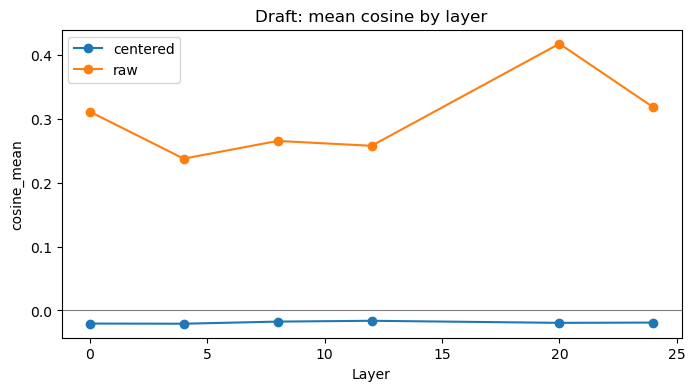

In [176]:
def plot_layer_metric(summary_df, y="cosine_mean", title=None):
    fig, ax = plt.subplots(figsize=(8, 4))
    for variant, sub in summary_df.groupby("metric_variant"):
        sub = sub.sort_values("layer")
        ax.plot(sub["layer"], sub[y], marker="o", label=str(variant))
    ax.axhline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Layer")
    ax.set_ylabel(y)
    ax.set_title(title or y)
    ax.legend()
    return fig, ax


def plot_cosine_hist(df, layer=None, metric_variant="raw", bins=50):
    sub = filter_metrics(df, layer=layer, metric_variant=metric_variant)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(sub["cosine"].dropna(), bins=bins, alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Cosine")
    ax.set_ylabel("Count")
    ax.set_title(f"Cosine histogram, layer={layer}, variant={metric_variant}")
    return fig, ax


def plot_cosine_hist_by_layer(df, layers=None, metric_variant="raw", bins=50):
    """Overlay cosine histograms from multiple layers in one draft diagnostic plot."""
    sub = filter_metrics(df, metric_variant=metric_variant)
    if layers is None:
        layers = sorted(sub["layer"].dropna().unique())
    layers = list(layers)

    fig, ax = plt.subplots(figsize=(8, 4.5))
    cmap = plt.get_cmap("tab10")
    for idx, layer in enumerate(layers):
        layer_values = sub.loc[sub["layer"] == layer, "cosine"].dropna()
        if layer_values.empty:
            continue
        ax.hist(
            layer_values,
            bins=bins,
            alpha=0.2,
            color=cmap(idx % 10),
            label=f"layer {layer}",
        )
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Cosine")
    ax.set_ylabel("Count")
    ax.set_title(f"Draft: cosine histograms by layer, variant={metric_variant}")
    ax.legend()
    return fig, ax


def plot_dot_hist(df, layer=None, metric_variant="raw", bins=50):
    """Plot a draft histogram of hidden-state dot products for one layer."""
    sub = filter_metrics(df, layer=layer, metric_variant=metric_variant)
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(sub["dot"].dropna(), bins=bins, alpha=0.8)
    ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("Dot product")
    ax.set_ylabel("Count")
    ax.set_title(f"Dot-product histogram, layer={layer}, variant={metric_variant}")
    return fig, ax


def plot_dot_hist_by_layer(df, layers=None, metric_variant="raw", bins=50, ncols=3):
    """Show hidden-state dot-product histograms from multiple layers as subplots."""
    sub = filter_metrics(df, metric_variant=metric_variant)
    if layers is None:
        layers = sorted(sub["layer"].dropna().unique())
    layers = list(layers)
    if not layers:
        raise ValueError("No layers available to plot.")

    ncols = min(ncols, len(layers))
    nrows = int(np.ceil(len(layers) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4.2 * ncols, 3.2 * nrows), squeeze=False)
    axes_flat = axes.ravel()

    for ax, layer in zip(axes_flat, layers):
        layer_values = sub.loc[sub["layer"] == layer, "dot"].dropna()
        ax.hist(layer_values, bins=bins, alpha=0.8)
        ax.axvline(0, color="black", linewidth=0.8, alpha=0.5)
        ax.set_title(f"Layer {layer}")
        ax.set_xlabel("Dot product")
        ax.set_ylabel("Count")

    for ax in axes_flat[len(layers):]:
        ax.axis("off")

    fig.suptitle(f"Draft: dot-product histograms by layer, variant={metric_variant}")
    fig.tight_layout()
    return fig, axes


plot_layer_metric(layer_summary, y="cosine_mean", title="Draft: mean cosine by layer");

In [177]:
sorted(metrics_df["layer"].dropna().unique())

[np.int64(0),
 np.int64(4),
 np.int64(8),
 np.int64(12),
 np.int64(20),
 np.int64(24)]

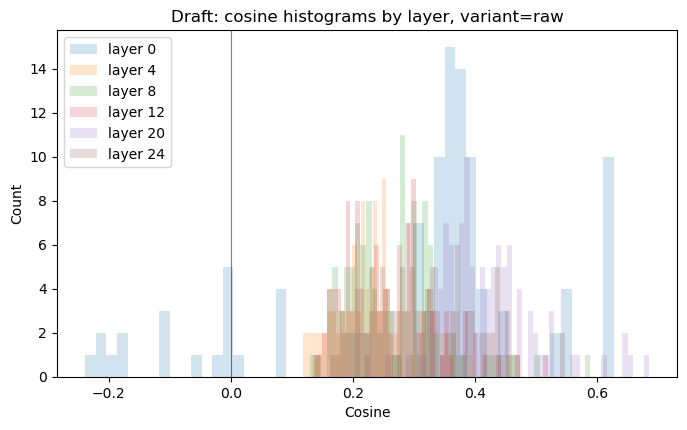

In [178]:
# # Change layer/variant as needed for quick inspection.
# example_layer = sorted(metrics_df["layer"].dropna().unique())[0]
# plot_cosine_hist(metrics_df, layer=example_layer, metric_variant="raw");

# Overlay a few layers in one image. Adjust the slice or pass explicit layers.
example_layers = sorted(metrics_df["layer"].dropna().unique())[::]
#example_layers = [0, 4, 12, 20, 28]
plot_cosine_hist_by_layer(metrics_df, layers=example_layers, metric_variant="raw");



In [179]:
# # Dot-product versions of the same quick checks.
# example_layer = sorted(metrics_df["layer"].dropna().unique())[1]
# plot_dot_hist(metrics_df, layer=example_layer, metric_variant="raw");
# # plot_dot_hist_by_layer(metrics_df, layers=example_layers, metric_variant="raw");

results/hh_dataset_combos/gsm8k_to_mmlu/Qwen3.5-0.8B/hh_alignment/pair_metrics.csv


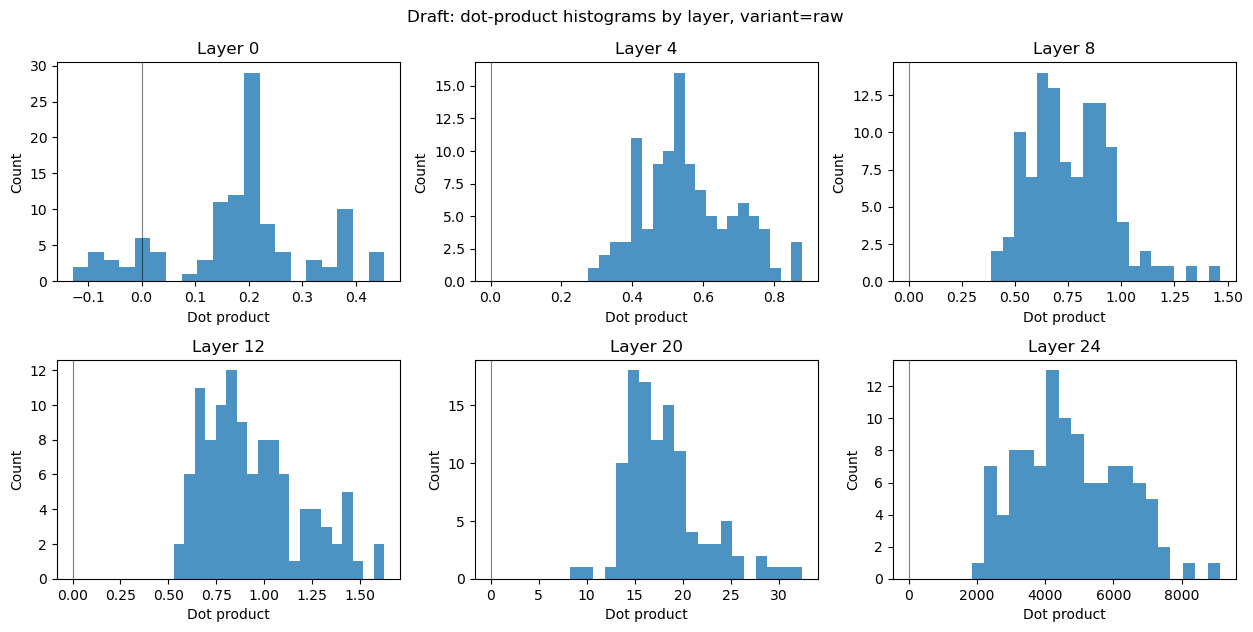

In [180]:
plot_dot_hist_by_layer(metrics_df, layers=example_layers,bins=20, metric_variant="raw");
print(csv_path)